# Macro vs Human 1차 분류 실험 노트북

- 입력: `collector_api/data/**/trial_*.json` 의 `metrics`
- 라벨: `summary.label` (`human`=0, `macro`=1)
- 기능: 학습/검증/시각화(Confusion Matrix, ROC/PR, score 분포, calibration)

In [9]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np

# services/ai 경로를 기준으로 실행되도록 세팅
# (노트북에서는 __file__ 이 없으므로, cwd와 parents를 훑어 `requirements.txt` + `macro/`가 있는 폴더를 찾는다)
AI_ROOT = None
cwd = Path.cwd().resolve()
for base in [cwd, *cwd.parents]:
    if (base / "requirements.txt").is_file() and (base / "macro").is_dir():
        AI_ROOT = base
        break

if AI_ROOT is None:
    raise RuntimeError(f"Could not locate services/ai root from cwd: {cwd}")

os.chdir(AI_ROOT)

print("AI_ROOT:", AI_ROOT)

AI_ROOT: C:\Users\SSAFY\Desktop\ws\free\S14P31A203\services\ai


In [10]:
import json
import re
from dataclasses import dataclass
from typing import Mapping

import pandas as pd

# ---- 설정 ----
TRIAL_GLOB = "macro/browser_automation/collector_api/data/**/trial_*.json"
LABEL_MAPPING = {"human": 0, "macro": 1}
INCLUDE_PATH_DERIVATIVES = True  # pre_click_mouse_path_pattern_* 파생 숫자 4개 포함

_PATH_PATTERN_RE = re.compile(r"(?P<dist>[0-9]+(?:\.[0-9]+)?)px\s*\|\s*straight\s*(?P<straight>[0-9]+(?:\.[0-9]+)?)")


def parse_mouse_path_pattern(value: object) -> tuple[float, float]:
    if not isinstance(value, str):
        return (float("nan"), float("nan"))
    m = _PATH_PATTERN_RE.search(value.strip())
    if not m:
        return (float("nan"), float("nan"))
    try:
        return (float(m.group("dist")), float(m.group("straight")))
    except Exception:
        return (float("nan"), float("nan"))


def to_float_or_nan(value: object) -> float:
    if value is None:
        return float("nan")
    if isinstance(value, bool):
        return float(int(value))
    if isinstance(value, (int, float)):
        return float(value)
    try:
        return float(value)  # type: ignore[arg-type]
    except Exception:
        return float("nan")


CLICK_FEATURES = [
    "time_to_first_click_ms",
    "time_from_element_visible_to_click_ms",
    "time_from_element_clickable_to_click_ms",
    "inter_click_interval_ms",
    "click_sequence_consistency_score",
    "click_position_repeat_rate",
    "click_offset_from_element_center_px",
    "click_offset_variance_px",
    "double_click_rate",
    "misclick_rate",
    "reclick_rate",
    "pre_click_mousemove_count",
    "pre_click_hover_time_ms",
    "pre_click_scroll_flag",
    "immediate_post_render_click_rate",
]

MOUSE_FEATURES_RAW = [
    "mouse_total_travel_distance_px",
    "mouse_avg_speed_px_per_ms",
    "mouse_max_speed_px_per_ms",
    "mouse_speed_change_mean",
    "mouse_acceleration_mean",
    "mouse_jerk_mean",
    "mouse_path_straightness_score",
    "mouse_path_curvature_mean",
    "mouse_direction_change_count",
    "mouse_overshoot_flag",
    "mouse_hover_dwell_time_ms",
    "mouse_stop_segment_count",
    "mousemove_event_rate",
    "inter_element_move_interval_std_ms",
    "edge_or_fixed_point_visit_rate",
    "pre_click_mouse_path_pattern_300ms",
    "pre_click_mouse_path_pattern_500ms",
]

MOUSE_FEATURES_DERIVED = [
    "pre_click_path_300ms_total_distance_px",
    "pre_click_path_300ms_straightness",
    "pre_click_path_500ms_total_distance_px",
    "pre_click_path_500ms_straightness",
]

KEYBOARD_FEATURES = [
    "time_to_first_keydown_ms",
    "inter_key_interval_ms_mean",
    "inter_key_interval_ms_std",
    "keydown_to_keyup_ms_mean",
    "typing_total_duration_ms",
    "typing_speed_cps",
    "backspace_rate",
    "correction_count",
    "paste_flag",
    "focus_to_submit_ms",
]


def feature_names(include_path_derivatives: bool) -> list[str]:
    mouse = [*MOUSE_FEATURES_RAW]
    if include_path_derivatives:
        mouse = [f for f in mouse if not f.startswith("pre_click_mouse_path_pattern_")]
        mouse.extend(MOUSE_FEATURES_DERIVED)
    return [*CLICK_FEATURES, *mouse, *KEYBOARD_FEATURES]


@dataclass(frozen=True)
class Dataset:
    x: np.ndarray
    y: np.ndarray
    paths: list[Path]
    label_mapping: dict[str, int]
    features: list[str]


def vectorize_metrics(metrics: Mapping[str, object], names: list[str], include_path_derivatives: bool) -> np.ndarray:
    derived: dict[str, float] = {}
    if include_path_derivatives:
        d300, s300 = parse_mouse_path_pattern(metrics.get("pre_click_mouse_path_pattern_300ms"))
        d500, s500 = parse_mouse_path_pattern(metrics.get("pre_click_mouse_path_pattern_500ms"))
        derived = {
            "pre_click_path_300ms_total_distance_px": d300,
            "pre_click_path_300ms_straightness": s300,
            "pre_click_path_500ms_total_distance_px": d500,
            "pre_click_path_500ms_straightness": s500,
        }

    row: list[float] = []
    for name in names:
        if name in derived:
            row.append(float(derived[name]))
        else:
            row.append(to_float_or_nan(metrics.get(name)))
    return np.asarray(row, dtype=np.float64)


def load_trials(ai_root: Path) -> Dataset:
    paths = sorted(ai_root.glob(TRIAL_GLOB))
    features = feature_names(INCLUDE_PATH_DERIVATIVES)

    rows: list[np.ndarray] = []
    labels: list[int] = []
    kept: list[Path] = []

    for p in paths:
        try:
            trial = json.loads(p.read_text(encoding="utf-8"))
        except Exception:
            continue

        summary = trial.get("summary") or {}
        label = summary.get("label") if isinstance(summary, dict) else None
        if label is None:
            continue
        label = str(label)
        if label not in LABEL_MAPPING:
            continue

        metrics = trial.get("metrics") or {}
        if not isinstance(metrics, dict):
            continue

        rows.append(vectorize_metrics(metrics, features, INCLUDE_PATH_DERIVATIVES))
        labels.append(LABEL_MAPPING[label])
        kept.append(p)

    x = np.stack(rows, axis=0) if rows else np.zeros((0, len(features)), dtype=np.float64)
    y = np.asarray(labels, dtype=np.int64) if labels else np.zeros((0,), dtype=np.int64)
    return Dataset(x=x, y=y, paths=kept, label_mapping=LABEL_MAPPING, features=features)


dataset = load_trials(AI_ROOT)
print("Loaded labeled trials:", dataset.x.shape, dataset.y.shape)
unique, counts = np.unique(dataset.y, return_counts=True)
print("Class counts (0=human, 1=macro):", dict(zip(unique.tolist(), counts.tolist())))
print("Feature count:", len(dataset.features))

pd.DataFrame({"feature": dataset.features}).head(20)

Loaded labeled trials: (585, 44) (585,)
Class counts (0=human, 1=macro): {0: 319, 1: 266}
Feature count: 44


,feature
0,time_to_first_click_ms
1,time_from_element_visible_to_click_ms
2,time_from_element_clickable_to_click_ms
3,inter_click_interval_ms
4,click_sequence_consistency_score
5,click_position_repeat_rate
6,click_offset_from_element_center_px
7,click_offset_variance_px
8,double_click_rate
9,misclick_rate


In [11]:
from sklearn.model_selection import train_test_split

SEED = 42
TEST_SIZE = 0.2

x_train, x_val, y_train, y_val = train_test_split(
    dataset.x,
    dataset.y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=dataset.y if np.unique(dataset.y).size >= 2 else None,
)

def fmt_counts(y: np.ndarray) -> str:
    u, c = np.unique(y, return_counts=True)
    return ", ".join(f"{int(k)}={int(v)}" for k, v in zip(u, c))

print(f"train: n={len(y_train)} ({fmt_counts(y_train)})")
print(f"val:   n={len(y_val)} ({fmt_counts(y_val)})")

train: n=468 (0=255, 1=213)
val:   n=117 (0=64, 1=53)


In [12]:
def row_hashes(x: np.ndarray) -> np.ndarray:
    filled = np.nan_to_num(x, nan=-9.87654321e9, posinf=9.87654321e9, neginf=-9.87654321e9)
    return np.asarray([hash(row.tobytes()) for row in filled], dtype=np.int64)

def duplicate_stats(x: np.ndarray, name: str) -> None:
    h = row_hashes(x)
    _, counts = np.unique(h, return_counts=True)
    dup_groups = int(np.sum(counts > 1))
    dup_rows = int(np.sum(counts[counts > 1] - 1))
    print(f"[{name}] dup_groups={dup_groups}, dup_rows={dup_rows}")

duplicate_stats(dataset.x, "all")
duplicate_stats(x_train, "train")
duplicate_stats(x_val, "val")

train_set = set(row_hashes(x_train).tolist())
val_set = set(row_hashes(x_val).tolist())
overlap = len(train_set.intersection(val_set))
print("[leakage] exact feature-row overlap train∩val:", overlap)

[all] dup_groups=261, dup_rows=261
[train] dup_groups=171, dup_rows=171
[val] dup_groups=12, dup_rows=12
[leakage] exact feature-row overlap train∩val: 78


In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def build_model(name: str, seed: int = 42):
    if name == "logreg":
        return Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=seed)),
            ]
        )
    if name == "hgb":
        return Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("clf", HistGradientBoostingClassifier(random_state=seed)),
            ]
        )
    if name == "rf":
        return Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "clf",
                    RandomForestClassifier(
                        n_estimators=600,
                        min_samples_leaf=2,
                        class_weight="balanced",
                        random_state=seed,
                        n_jobs=-1,
                    ),
                ),
            ]
        )
    raise ValueError(name)


def predict_proba_binary(model, x: np.ndarray) -> np.ndarray:
    proba = model.predict_proba(x)
    return np.asarray(proba)[:, 1]


def eval_metrics(y_true: np.ndarray, proba: np.ndarray) -> dict:
    pred = (proba >= 0.5).astype(int)
    out = {
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
    }
    try:
        out["roc_auc"] = float(roc_auc_score(y_true, proba))
    except Exception:
        out["roc_auc"] = float("nan")
    return out


results = []
models = {}
for name in ["logreg", "hgb", "rf"]:
    model = build_model(name, seed=SEED)
    model.fit(x_train, y_train)
    proba = predict_proba_binary(model, x_val)
    m = eval_metrics(y_val, proba)
    results.append({"model": name, **m})
    models[name] = (model, proba)

pd.DataFrame(results).sort_values("roc_auc", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
0,logreg,1.0,1.0,1.0,1.0,1.0
1,hgb,1.0,1.0,1.0,1.0,1.0
2,rf,1.0,1.0,1.0,1.0,1.0


BEST: logreg


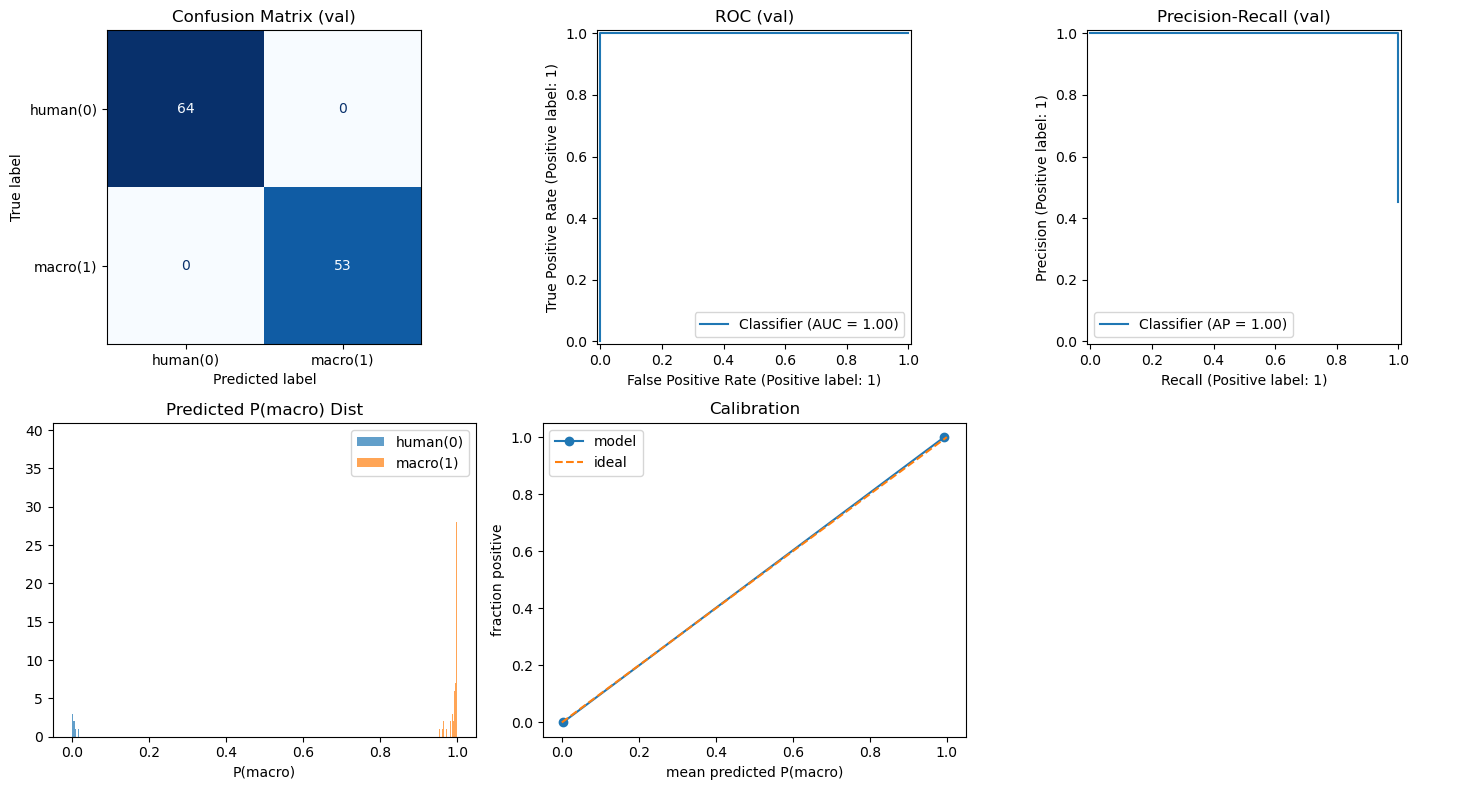

In [14]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay, confusion_matrix

# best model 선택 (roc_auc 기준)
best = pd.DataFrame(results).sort_values("roc_auc", ascending=False).iloc[0]["model"]
model, proba = models[str(best)]
pred = (proba >= 0.5).astype(int)

print("BEST:", best)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

# Confusion
cm = confusion_matrix(y_val, pred, labels=[0, 1])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["human(0)", "macro(1)"]).plot(
    ax=axes[0], cmap="Blues", values_format="d", colorbar=False
)
axes[0].set_title("Confusion Matrix (val)")

# ROC
RocCurveDisplay.from_predictions(y_val, proba, ax=axes[1])
axes[1].set_title("ROC (val)")

# PR
PrecisionRecallDisplay.from_predictions(y_val, proba, ax=axes[2])
axes[2].set_title("Precision-Recall (val)")

# Score hist
axes[3].hist(proba[y_val == 0], bins=20, alpha=0.7, label="human(0)")
axes[3].hist(proba[y_val == 1], bins=20, alpha=0.7, label="macro(1)")
axes[3].set_title("Predicted P(macro) Dist")
axes[3].set_xlabel("P(macro)")
axes[3].legend()

# Calibration
frac_pos, mean_pred = calibration_curve(y_val, proba, n_bins=10, strategy="uniform")
axes[4].plot(mean_pred, frac_pos, marker="o", label="model")
axes[4].plot([0, 1], [0, 1], linestyle="--", label="ideal")
axes[4].set_title("Calibration")
axes[4].set_xlabel("mean predicted P(macro)")
axes[4].set_ylabel("fraction positive")
axes[4].legend()

# empty
axes[5].axis("off")

fig.tight_layout()
plt.show()

In [15]:
# (선택) logreg 계수로 어떤 feature가 강하게 작동하는지 빠르게 보기
logreg_model = models["logreg"][0]
clf = logreg_model.named_steps["clf"]
coef = clf.coef_.reshape(-1)
df_coef = pd.DataFrame({"feature": dataset.features, "coef": coef}).sort_values("coef", ascending=False)
display(df_coef.head(15))
display(df_coef.tail(15))

,feature,coef
30,pre_click_path_300ms_total_distance_px,0.824055
25,mouse_hover_dwell_time_ms,0.689183
32,pre_click_path_500ms_total_distance_px,0.405228
37,keydown_to_keyup_ms_mean,0.318023
18,mouse_speed_change_mean,0.292823
21,mouse_path_straightness_score,0.241000
0,time_to_first_click_ms,0.236200
16,mouse_avg_speed_px_per_ms,0.172376
38,typing_total_duration_ms,0.135936
33,pre_click_path_500ms_straightness,0.124336


,feature,coef
22,mouse_path_curvature_mean,-0.196729
8,double_click_rate,-0.215955
1,time_from_element_visible_to_click_ms,-0.225821
2,time_from_element_clickable_to_click_ms,-0.225821
14,immediate_post_render_click_rate,-0.228259
3,inter_click_interval_ms,-0.273154
36,inter_key_interval_ms_std,-0.332248
43,focus_to_submit_ms,-0.430875
28,inter_element_move_interval_std_ms,-0.504624
26,mouse_stop_segment_count,-0.552779


In [16]:
# (선택) artifact 저장: 나중에 서빙/스크립트 report에 활용
import json
from datetime import datetime

SAVE_ARTIFACT = True
ARTIFACT_DIR = None  # 예: AI_ROOT / "models" / "classifier" / "artifacts" / "<timestamp>_nb"

if SAVE_ARTIFACT:
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = Path(ARTIFACT_DIR) if ARTIFACT_DIR else AI_ROOT / "artifacts" / f"{ts}_nb_{best}"
    out_dir.mkdir(parents=True, exist_ok=True)
    meta = {
        "trained_at": ts,
        "model_family": str(best),
        "include_path_derivatives": INCLUDE_PATH_DERIVATIVES,
        "feature_names": list(dataset.features),
        "label_mapping": dataset.label_mapping,
        "n_samples": int(dataset.x.shape[0]),
        "n_train": int(x_train.shape[0]),
        "n_val": int(x_val.shape[0]),
        "val_metrics": dict(pd.DataFrame(results).set_index("model").loc[str(best)]),
    }
    try:
        import joblib
    except Exception as exc:
        raise RuntimeError("joblib not installed. `pip install joblib` or install scikit-learn which includes it.") from exc

    joblib.dump(model, out_dir / "model.joblib")
    (out_dir / "meta.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
    print("Saved:", out_dir)
else:
    print("SAVE_ARTIFACT=False (skip)")

Saved: C:\Users\SSAFY\Desktop\ws\free\S14P31A203\services\ai\artifacts\20260422_151740_nb_logreg
